In [32]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy import stats
import tensorflow as tf
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split

%matplotlib inline

In [33]:
import seaborn as sns
sns.set(style="whitegrid", palette="muted", font_scale=1.5)
RANDOM_SEED = 42

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
from google.colab import files
uploaded = files.upload()

Saving human+activity+recognition+using+smartphones.zip to human+activity+recognition+using+smartphones (3).zip


In [35]:
list(uploaded.keys())

['human+activity+recognition+using+smartphones (3).zip']

In [36]:
import zipfile
import io

# Extract outer zip
with zipfile.ZipFile('human+activity+recognition+using+smartphones.zip', 'r') as z:
    z.extractall('outer')

# Extract inner zip
with zipfile.ZipFile('outer/UCI HAR Dataset.zip', 'r') as z:
    z.extractall('har_data')

In [37]:
import pandas as pd

df = pd.read_csv(
    'har_data/UCI HAR Dataset/train/X_train.txt',
    sep=r'\s+',
    header=None
)

df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [38]:
df.shape

(7352, 561)

In [39]:
import os

for root, dirs, files in os.walk("har_data"):
    print(root)

har_data
har_data/UCI HAR Dataset
har_data/UCI HAR Dataset/test
har_data/UCI HAR Dataset/test/Inertial Signals
har_data/UCI HAR Dataset/train
har_data/UCI HAR Dataset/train/Inertial Signals
har_data/__MACOSX
har_data/__MACOSX/UCI HAR Dataset
har_data/__MACOSX/UCI HAR Dataset/test
har_data/__MACOSX/UCI HAR Dataset/test/Inertial Signals
har_data/__MACOSX/UCI HAR Dataset/train
har_data/__MACOSX/UCI HAR Dataset/train/Inertial Signals


In [40]:
train_path = "har_data/UCI HAR Dataset/train/"
test_path  = "har_data/UCI HAR Dataset/test/"

In [41]:
import pandas as pd

X_train = pd.read_csv(
    train_path + "X_train.txt",
    sep=r"\s+",
    header=None
)

X_test = pd.read_csv(
    test_path + "X_test.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    train_path + "y_train.txt",
    header=None
)

y_test = pd.read_csv(
    test_path + "y_test.txt",
    header=None
)

In [42]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7352, 561)
X_test : (2947, 561)
y_train: (7352, 1)
y_test : (2947, 1)


In [43]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(7352, 561)
(2947, 561)
(7352, 1)
(2947, 1)


In [44]:
y_train = y_train[0] - 1
y_test = y_test[0] - 1

In [46]:
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)

# The previous np.squeeze operations are not needed as to_categorical directly produces the correct shape.
# y_train = np.squeeze(y_train, axis=1)
# y_test = np.squeeze(y_test, axis=1)

In [47]:
X_train = X_train.values.reshape(
    X_train.shape[0],
    1,
    X_train.shape[1]
)

X_test = X_test.values.reshape(
    X_test.shape[0],
    1,
    X_test.shape[1]
)

In [48]:
print(X_train.shape)
print(X_test.shape)

(7352, 1, 561)
(2947, 1, 561)


In [49]:
from tensorflow.keras.models import Sequential

model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(1, 561),
        return_sequences=False
    )
)

model.add(Dropout(0.5))

model.add(Dense(64, activation="relu"))

model.add(Dense(6, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │       160,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,806 (643.77 KB)

 Trainable params: 164,806 (643.77 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Clear any previous TensorFlow/Keras session state to prevent tf.function graph-building errors.
tf.keras.backend.clear_session()

# Recreate the model definition
model = Sequential()
model.add(
    LSTM(
        64,
        input_shape=(1, 561),
        return_sequences=False
    )
)
model.add(Dropout(0.5))
model.add(Dense(64, activation="relu"))
model.add(Dense(6, activation="softmax"))

# Recompile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Ensure y_train and y_test have the correct 2D shape (num_samples, num_classes)
# This handles cases where to_categorical might have added an extra dimension previously.
y_train = y_train[:, 0, :] if y_train.ndim == 3 else y_train
y_test = y_test[:, 0, :] if y_test.ndim == 3 else y_test

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8677 - loss: 0.3430 - val_accuracy: 0.9905 - val_loss: 0.0664
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9813 - loss: 0.0592 - val_accuracy: 0.9973 - val_loss: 0.0188
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9869 - loss: 0.0372 - val_accuracy: 0.9980 - val_loss: 0.0081
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9915 - loss: 0.0235 - val_accuracy: 0.9986 - val_loss: 0.0041
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9929 - loss: 0.0214 - val_accuracy: 0.9980 - val_loss: 0.0074
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9937 - loss: 0.0176 - val_accuracy: 0.9986 - val_loss: 0.0031
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9949 - loss: 0.0139 - val_accuracy: 0.9993 - val_loss: 0.0028
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9934 - loss: 0.0178 - val_accuracy: 0.9986 - val_loss: 0.0036
Ep

In [55]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.023322127759456635
Test Accuracy: 0.9921954274177551


In [56]:
predictions = model.predict(X_test)

pred_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = np.argmax(
    y_test,
    axis=1
)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [57]:
print(
    classification_report(
        true_classes,
        pred_classes
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2451
           1       0.97      0.99      0.98       496

    accuracy                           0.99      2947
   macro avg       0.98      0.99      0.99      2947
weighted avg       0.99      0.99      0.99      2947



In [58]:
cm = confusion_matrix(
    true_classes,
    pred_classes
)

print(cm)

[[2435   16]
 [   7  489]]


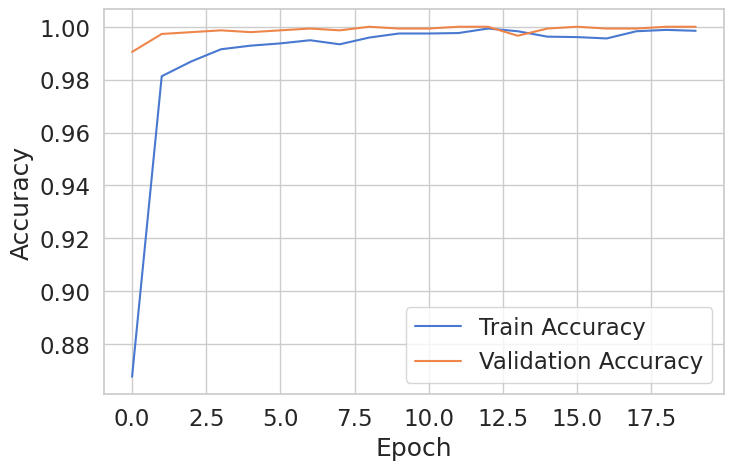

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()